# Comparing 1PAT1R vs KerrEccEq waveforms

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

In [38]:
# --- Define Parameters ---
m1 = 1e6      # primary mass [solar masses]
m2 = 1e4       # secondary mass [solar masses]
chi1  = 1e-3
a = chi1      # primary spin chi1 (dimensionless)
p0 = 9.0      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [39]:
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

WFKerr0PA = FastKerrEccentricEquatorialFlux()
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds

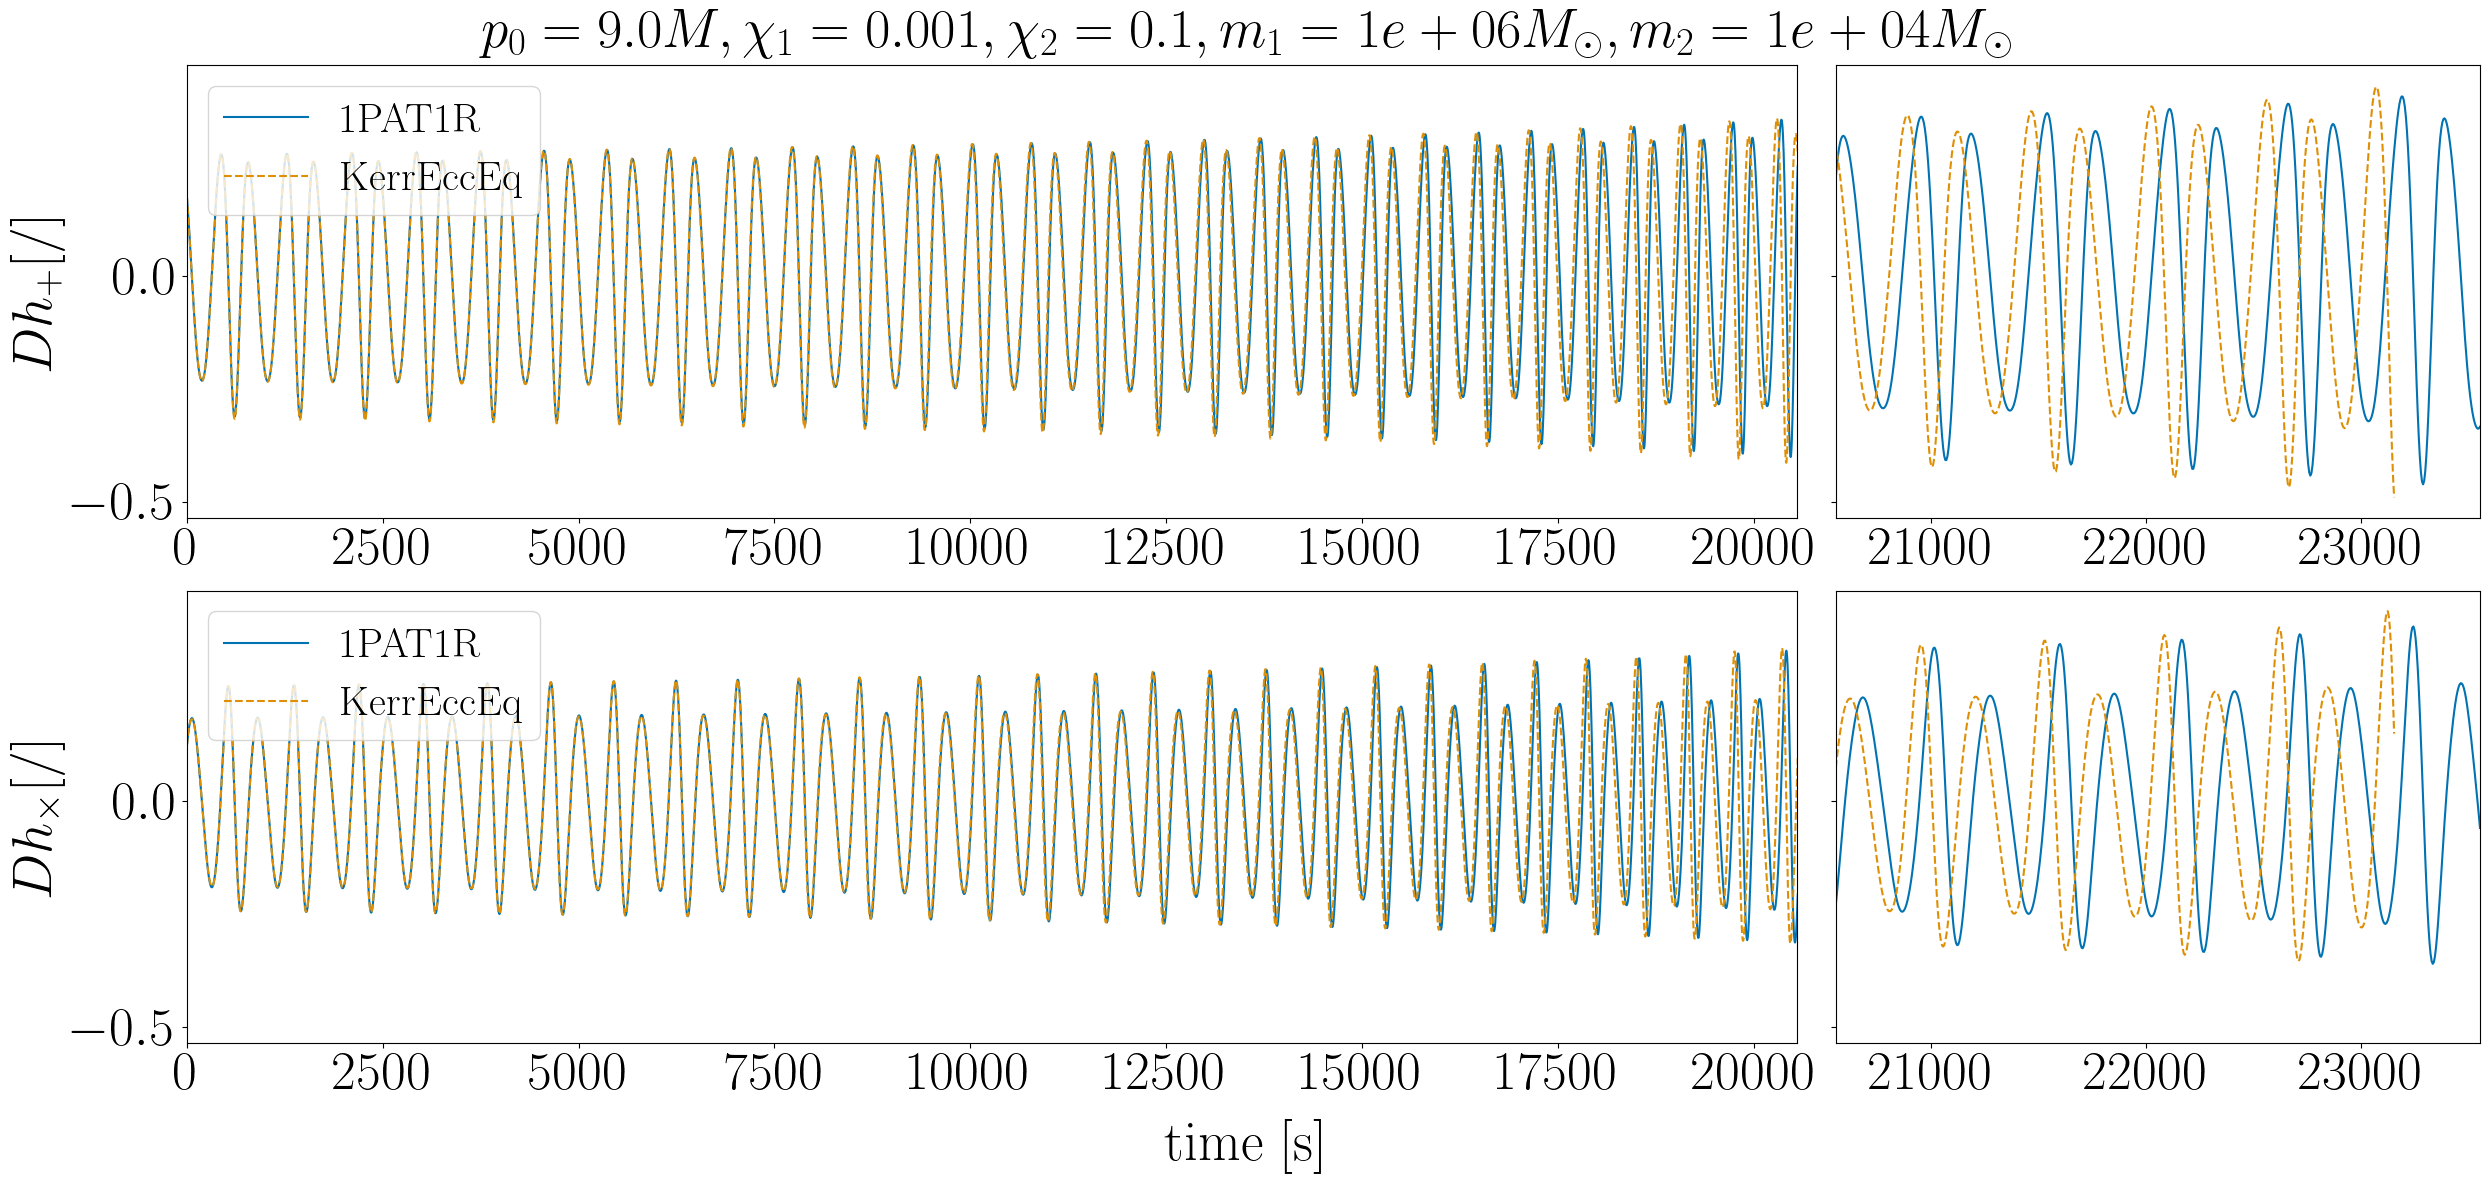

In [59]:
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]
tZoom = 3000
fontsize = 40

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

fig, axs = plt.subplots(2, 2, figsize=(25,12), gridspec_kw={'width_ratios': [5, 2]}, sharey=True, tight_layout=True)

fig.suptitle(rf"$p_0={p0}M, \chi_1={a}, \chi_2={chi2}, m_1 ={m1:.0e}M_\odot, m_2={m2:.0e}M_\odot$", fontsize=fontsize)
fig.supxlabel('time [s]', fontsize=fontsize)

axs[0,0].plot(t1PA, h1PAT1R.real, label='1PAT1R', color=colorblind_hex[0])
axs[0,0].plot(tKerr, hKerr.real, label='KerrEccEq', color=colorblind_hex[1], linestyle='--')
axs[0,0].set_xlim(t1PA[0], t1PA[-1]-tZoom)
axs[0,0].set_ylabel(rf'$D h_+ [/]$', fontsize=fontsize)
axs[0,0].legend(fontsize=fontsize-10, loc='upper left')
axs[0,0].tick_params(labelsize=fontsize-1)

axs[0,1].plot(t1PA, h1PAT1R.real, label='1PAT1R', color=colorblind_hex[0])
axs[0,1].plot(tKerr, hKerr.real, label='KerrEccEq', color=colorblind_hex[1], linestyle='--')
axs[0,1].set_xlim(t1PA[-1]-tZoom, t1PA[-1])
axs[0,1].tick_params(labelsize=fontsize-1)


axs[1,0].plot(t1PA, -h1PAT1R.imag, label='1PAT1R', color=colorblind_hex[0])
axs[1,0].plot(tKerr, -hKerr.imag, label='KerrEccEq', color=colorblind_hex[1], linestyle='--')
axs[1,0].set_xlim(t1PA[0], t1PA[-1]-tZoom)
axs[1,0].set_ylabel(rf'$D h_\times [/]$', fontsize=fontsize)
axs[1,0].legend(fontsize=fontsize-10, loc='upper left')
axs[1,0].tick_params(labelsize=fontsize-1)

axs[1,1].plot(t1PA, -h1PAT1R.imag, label='1PAT1R', color=colorblind_hex[0])
axs[1,1].plot(tKerr, -hKerr.imag, label='KerrEccEq', color=colorblind_hex[1], linestyle='--')
axs[1,1].set_xlim(t1PA[-1]-tZoom, t1PA[-1])
axs[1,1].tick_params(labelsize=fontsize-1)
